# Parameter Estimation

In [12]:
import sys
sys.path.append("../..")
from src.point_process import *
from src.utils import g_theo_thomas
from src.utils import contrast
import json

**Simulating a Thomas process**

In [13]:
with open('../../parameters/thomas-process-m-03.json', 'r') as file:
    params = json.load(file)

In [14]:
W = params['W']
w, h = W
lam_p = params['lam_p']
nu = params['nu']
sig = params['sig']

In [15]:
thomas_process = ThomasProcess(lam_p, nu, sig)
parents, points_thomas = thomas_process.generate(W, seed=46)

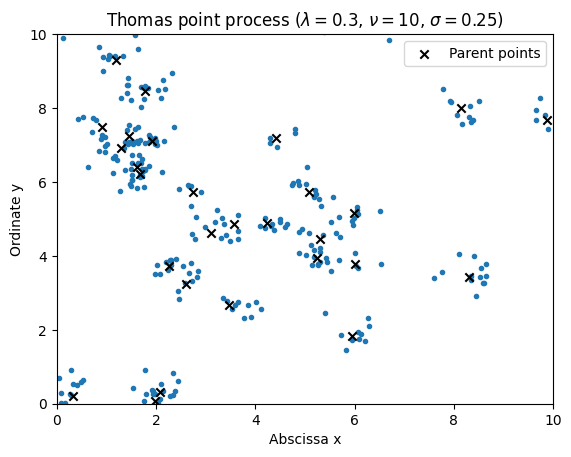

In [16]:
display(parents, points_thomas, window=(10, 10), title=fr"Thomas point process ($\lambda = {lam_p}$, $\nu = {nu}$, $\sigma = {sig}$)")

**Estimating the parameters**

As $g$ only depends on $\lambda_p$ and $\sigma$, we will define our parameter vector $\theta = (\lambda_p, \sigma)$

In [17]:
r_values, g_values = g(points_thomas, W)  # Estimating the p.c.f

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages

R[write to console]: 2: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages



In [18]:
threshold = 10  # For radii smaller than the bandwidth, the estimator explodes
r_values = r_values[threshold:]
g_values = g_values[threshold:]

In [19]:
def contrast_aux(theta):  # Auxiliary contrast function that takes theta as a parameter
    g_theo_list = g_theo_thomas(r_values, theta)
    dr = r_values[1] - r_values[0]
    return contrast(g_values, g_theo_list, dr)

In [20]:
theta0 = [0.5, 1]  # Initial guess

bounds = [(1e-6, None), (1e-6, None)]  # Positivity constraints

result = minimize(contrast_aux, theta0, method='L-BFGS-B', bounds=bounds)

print('Estimated parameters:\n------------------')
print(f'estimated_lam_p = {result.x[0]:.3f}')
print(f'estimated_nu = {intensity(points_thomas, W)/result.x[0]:.3f}')
print(f'estimated_sig = {result.x[1]:.3f}')
print('\nReal parameters:\n------------------')
print(f'lam_p = {lam_p:.3f}')
print(f'nu = {nu:.3f}')
print(f'sig = {sig:.3f}')
print('\nRelative error:\n------------------')
print(f'lam_p --> {100*abs(lam_p - result.x[0])/lam_p:.2f} %')
print(f'nu --> {100*abs(nu - intensity(points_thomas, W)/result.x[0])/nu:.2f} %')
print(f'sig --> {100*abs(sig - result.x[1])/sig:.2f} %')

Estimated parameters:
------------------
estimated_lam_p = 0.287
estimated_nu = 11.026
estimated_sig = 0.261

Real parameters:
------------------
lam_p = 0.300
nu = 10.000
sig = 0.250

Relative error:
------------------
lam_p --> 4.23 %
nu --> 10.26 %
sig --> 4.51 %
